# Imports

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import seaborn as sns #I like the visuals better than matplotlib. Is that ok? if not import matplotlib
import sys
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt


In [39]:
sys.path.insert(0,"..")
from src.data import load
# Download latest version
file_path = "uciml/default-of-credit-card-clients-dataset"
df = load.get_kaggle_data(file_path)


In [40]:
print(df.head(), df.dtypes, df.isnull().sum())
df['PAY_0'].value_counts()

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

# EDA

In [41]:
df = df.rename(columns={'default.payment.next.month': 'target'})
X = df.drop('target', axis = 1)
y = df['target']

print(y.value_counts())
y_negs = y[y==0].count()
y_pos = y[y==1].count()

weight_adjust = float(y_negs.sum()/y_pos.sum())
print(weight_adjust)


target
0    23364
1     6636
Name: count, dtype: int64
3.5207956600361663


<Axes: xlabel='target'>

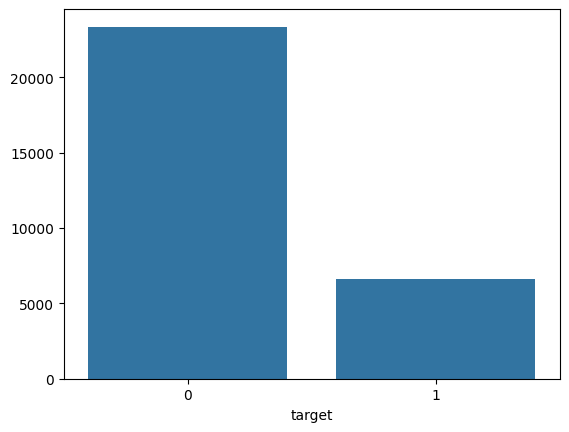

In [42]:
sns.barplot(x=y.value_counts().index, y=y.value_counts().values)

<Axes: >

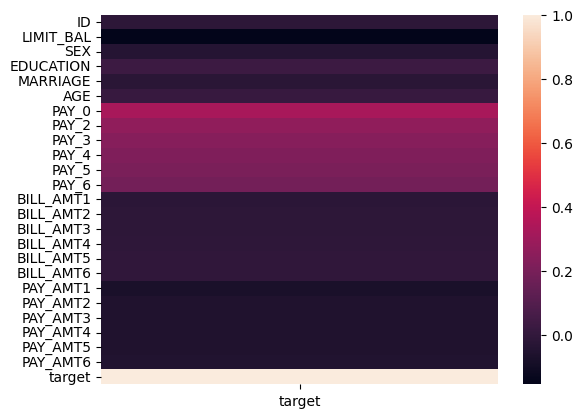

In [43]:
sns.heatmap(df.corr()[['target']])

#### Getting a better understanding of all the variables.

##### Payment Status

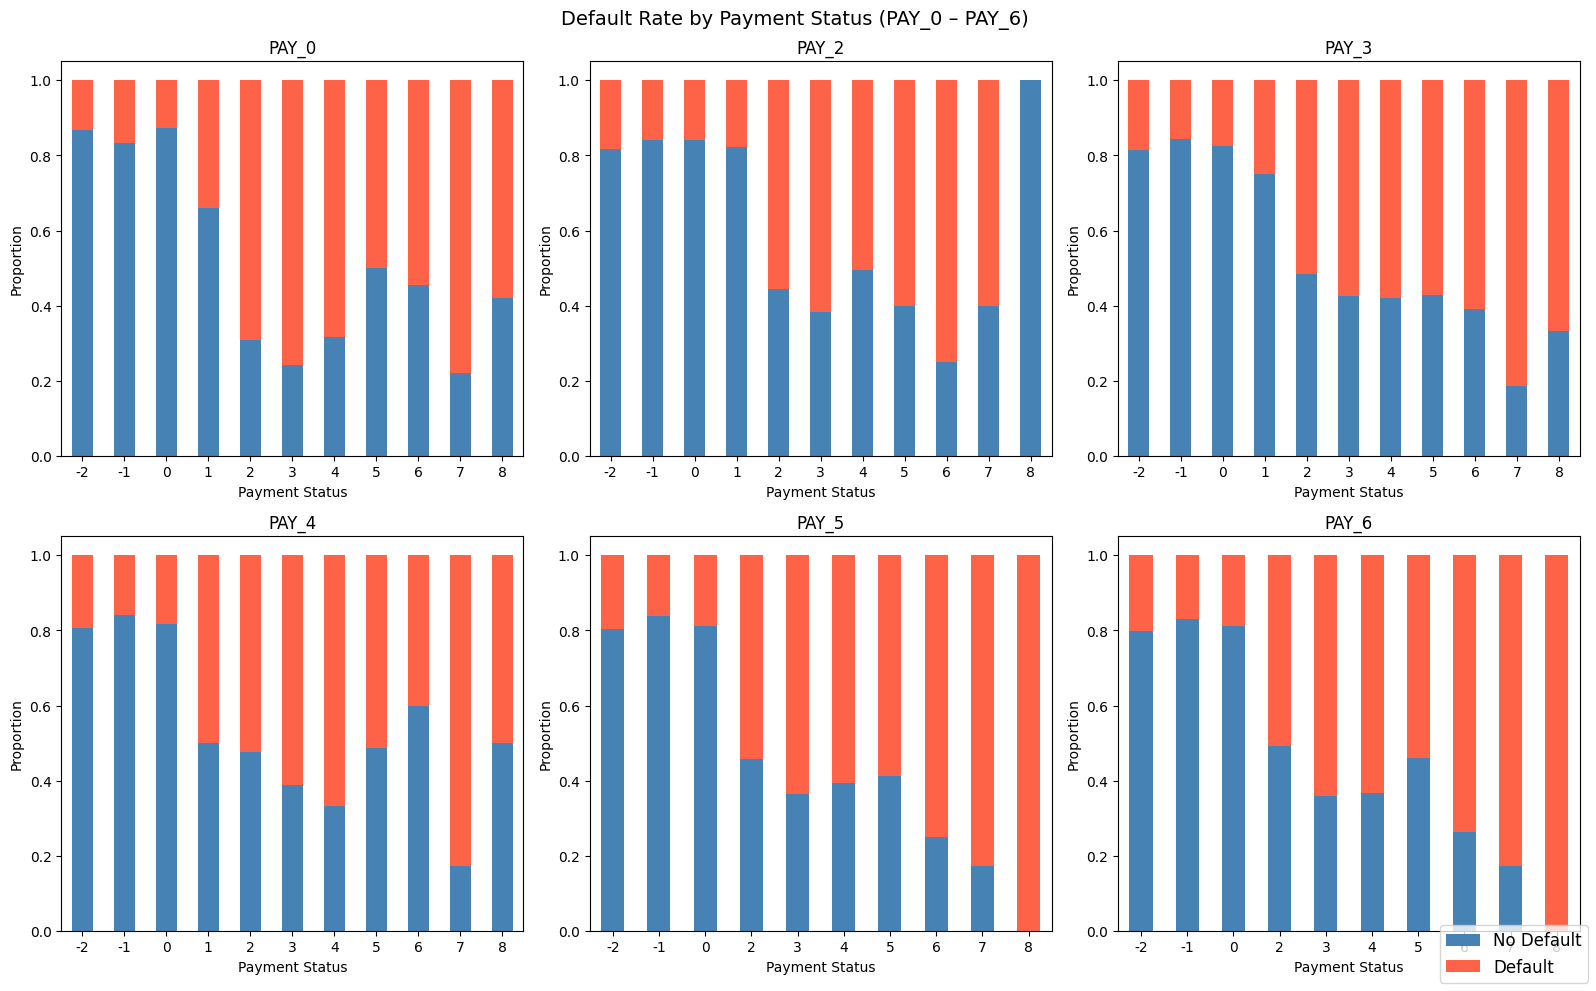

In [44]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    groups = df.groupby(col)['target'].value_counts(normalize=True).unstack()
    groups.plot(kind='bar', stacked=True, ax=axes[i], color=['steelblue', 'tomato'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Payment Status')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Default', 'Default'], loc='lower right', fontsize=12)
fig.suptitle('Default Rate by Payment Status (PAY_0 – PAY_6)', fontsize=14)
plt.tight_layout()
plt.show()


##### Limit Balance

/var/folders/dd/g3qjwl594ynbk5c9ygbg1bvc0000gn/T/ipykernel_93538/454620743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='LIMIT_BAL', ax=ax, palette=['steelblue', 'tomato'])


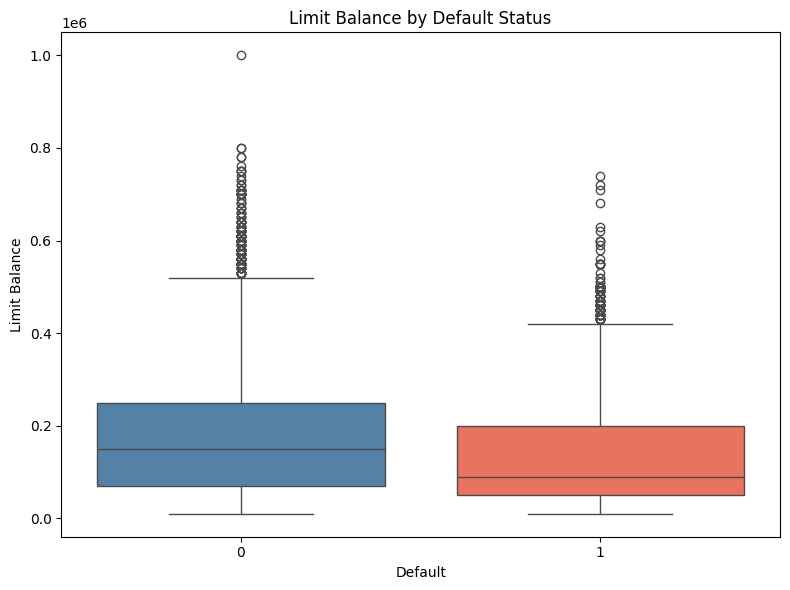

In [45]:
limit_cols = ['LIMIT_BAL']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='target', y='LIMIT_BAL', ax=ax, palette=['steelblue', 'tomato'])
ax.set_title('Limit Balance by Default Status')
ax.set_xlabel('Default')
ax.set_ylabel('Limit Balance')
plt.tight_layout()
plt.show()



##### Bill Amounts

/var/folders/dd/g3qjwl594ynbk5c9ygbg1bvc0000gn/T/ipykernel_93538/3841282347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['steelblue', 'tomato'])
/var/folders/dd/g3qjwl594ynbk5c9ygbg1bvc0000gn/T/ipykernel_93538/3841282347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['steelblue', 'tomato'])
/var/folders/dd/g3qjwl594ynbk5c9ygbg1bvc0000gn/T/ipykernel_93538/3841282347.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='targe

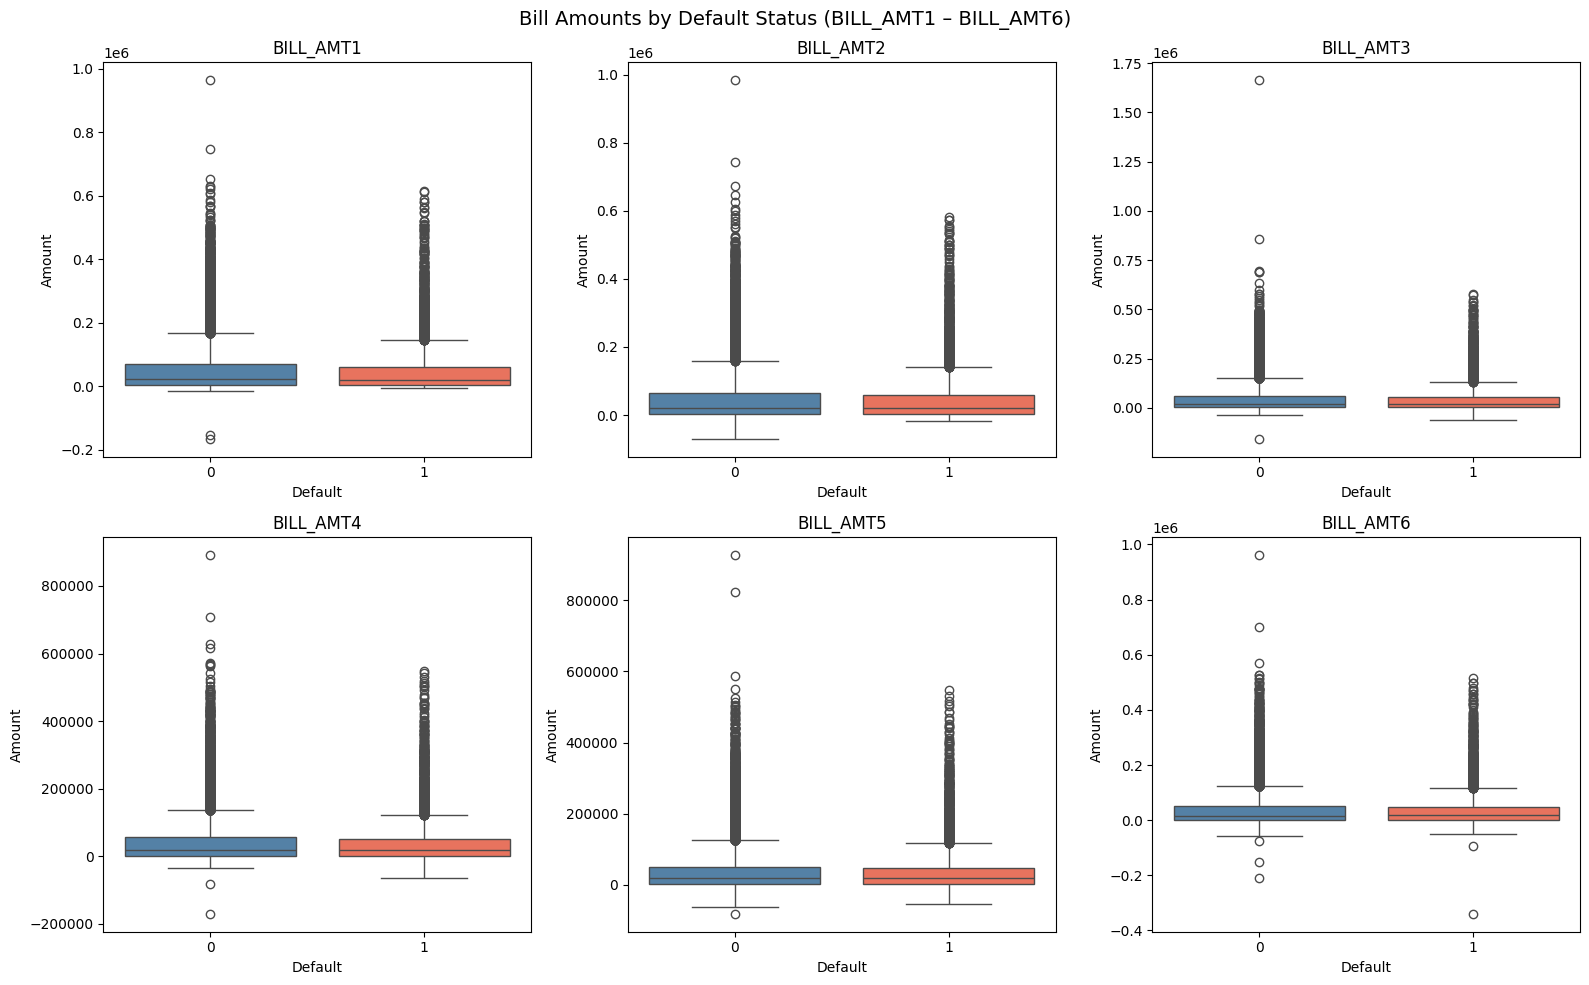

In [46]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for i, col in enumerate(bill_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['steelblue', 'tomato'])
    axes[i].set_title(col)
    axes[i].set_xlabel('Default')
    axes[i].set_ylabel('Amount')

fig.suptitle('Bill Amounts by Default Status (BILL_AMT1 – BILL_AMT6)', fontsize=14)
plt.tight_layout()
plt.show()


##### Demographics

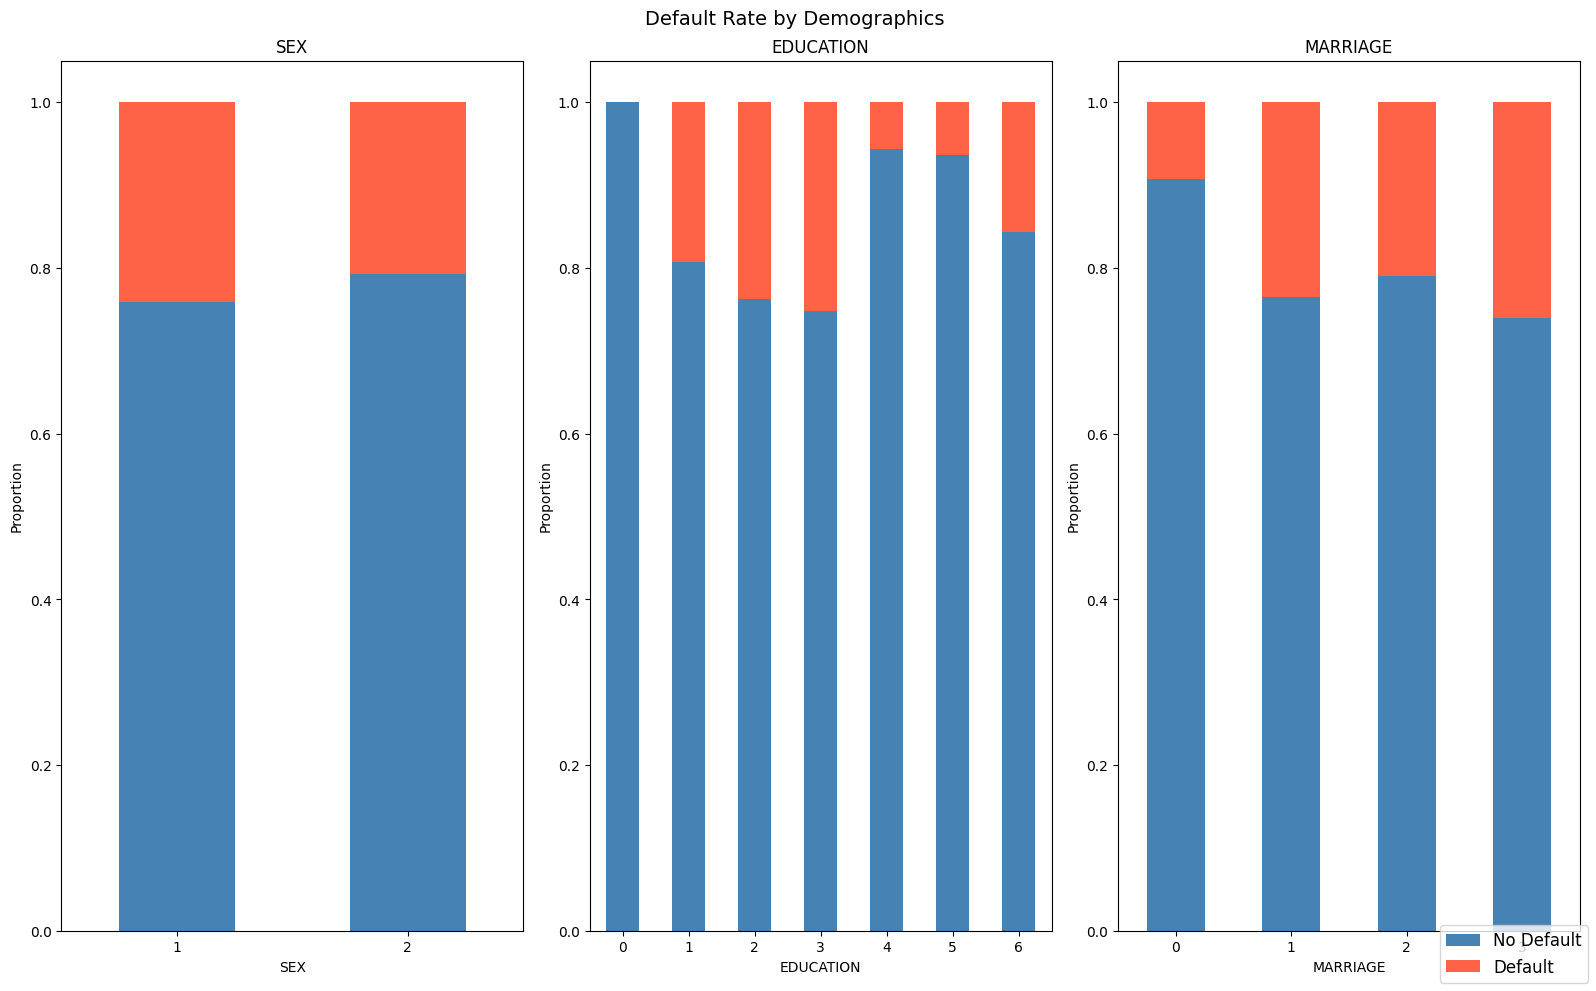

In [47]:
cat_cols = ['SEX', 'EDUCATION','MARRIAGE']

fig, axes = plt.subplots(1, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    groups = df.groupby(col)['target'].value_counts(normalize=True).unstack()
    groups.plot(kind='bar', stacked=True, ax=axes[i], color=['steelblue', 'tomato'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Default', 'Default'], loc='lower right', fontsize=12)
fig.suptitle('Default Rate by Demographics', fontsize=14)
plt.tight_layout()
plt.show()

##### Education

In [48]:
print(df['EDUCATION'].value_counts())
print(df.groupby('EDUCATION')['target'].value_counts(normalize=True).unstack())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
target            0         1
EDUCATION                    
0          1.000000       NaN
1          0.807652  0.192348
2          0.762651  0.237349
3          0.748424  0.251576
4          0.943089  0.056911
5          0.935714  0.064286
6          0.843137  0.156863


## Models

#### Note: need to combine 0,4,5,6 into 'Others' at some point

In [49]:
from src.models import train, evaluate, explain

In [50]:
X_train, X_test, y_train, y_test = train.split_data(df, 'target', 0.2)

### Gradient Boost

#### Get Base Model

In [51]:
model = train.data_model(X_train, y_train, xgb(scale_pos_weight=weight_adjust, base_score=0.5, random_state=42))
base_vals = evaluate.evaluate_model(model, X_test, y_test, output_dict=True)
print(evaluate.evaluate_model(model, X_test, y_test, output_dict=True))

{'0': {'precision': 0.8762672811059908, 'recall': 0.8113932152762962, 'f1-score': 0.842583361028027, 'support': 4687.0}, '1': {'precision': 0.4674698795180723, 'recall': 0.591012947448591, 'f1-score': 0.5220316178943828, 'support': 1313.0}, 'accuracy': 0.7631666666666667, 'macro avg': {'precision': 0.6718685803120316, 'recall': 0.7012030813624436, 'f1-score': 0.6823074894612049, 'support': 6000.0}, 'weighted avg': {'precision': 0.7868087830585012, 'recall': 0.7631666666666667, 'f1-score': 0.7724359545722812, 'support': 6000.0}}


### Tune Hyperparameters

In [52]:
hyperparam_tuning = RandomizedSearchCV(estimator=xgb(scale_pos_weight=weight_adjust, base_score=0.5, random_state=42),
                                       n_iter=10,
                                       param_distributions={'max_depth': [4,5,6],
                                                            'n_estimators': range(100,500),
                                                            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                       scoring='recall',
                                       random_state=42).fit(X_train, y_train)

In [53]:
model_tuned = train.data_model(X_train, y_train, 
                               xgb(scale_pos_weight=weight_adjust, 
                                   base_score=0.5,
                                   random_state=42,
                                   max_depth=hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators=hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate=hyperparam_tuning.best_params_['learning_rate']))
tuned_vals = evaluate.evaluate_model(model_tuned, X_test, y_test, output_dict=True)

print(base_vals, tuned_vals)

{'0': {'precision': 0.8762672811059908, 'recall': 0.8113932152762962, 'f1-score': 0.842583361028027, 'support': 4687.0}, '1': {'precision': 0.4674698795180723, 'recall': 0.591012947448591, 'f1-score': 0.5220316178943828, 'support': 1313.0}, 'accuracy': 0.7631666666666667, 'macro avg': {'precision': 0.6718685803120316, 'recall': 0.7012030813624436, 'f1-score': 0.6823074894612049, 'support': 6000.0}, 'weighted avg': {'precision': 0.7868087830585012, 'recall': 0.7631666666666667, 'f1-score': 0.7724359545722812, 'support': 6000.0}} {'0': {'precision': 0.8788238083945933, 'recall': 0.7906976744186046, 'f1-score': 0.8324348607367476, 'support': 4687.0}, '1': {'precision': 0.44980370162647226, 'recall': 0.6108149276466108, 'f1-score': 0.5180878552971576, 'support': 1313.0}, 'accuracy': 0.7513333333333333, 'macro avg': {'precision': 0.6643137550105328, 'recall': 0.7007563010326077, 'f1-score': 0.6752613580169526, 'support': 6000.0}, 'weighted avg': {'precision': 0.7849399083635029, 'recall': 0

In [54]:
print(hyperparam_tuning.best_params_)

{'n_estimators': 272, 'max_depth': 4, 'learning_rate': 0.2}


##### Confusion Matrix

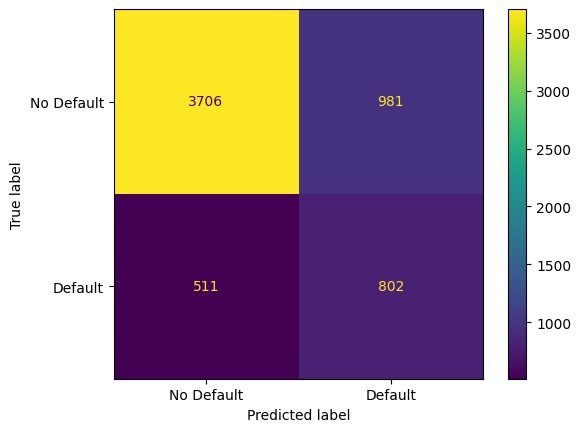

In [55]:
y_pred_xgb = model_tuned.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default','Default'])
disp.plot()
plt.show()

### Evaluate AUC-PR

In [56]:
xgb_auc = evaluate.auc_eval(model_tuned, X_test, y_test)

### SHAP Values

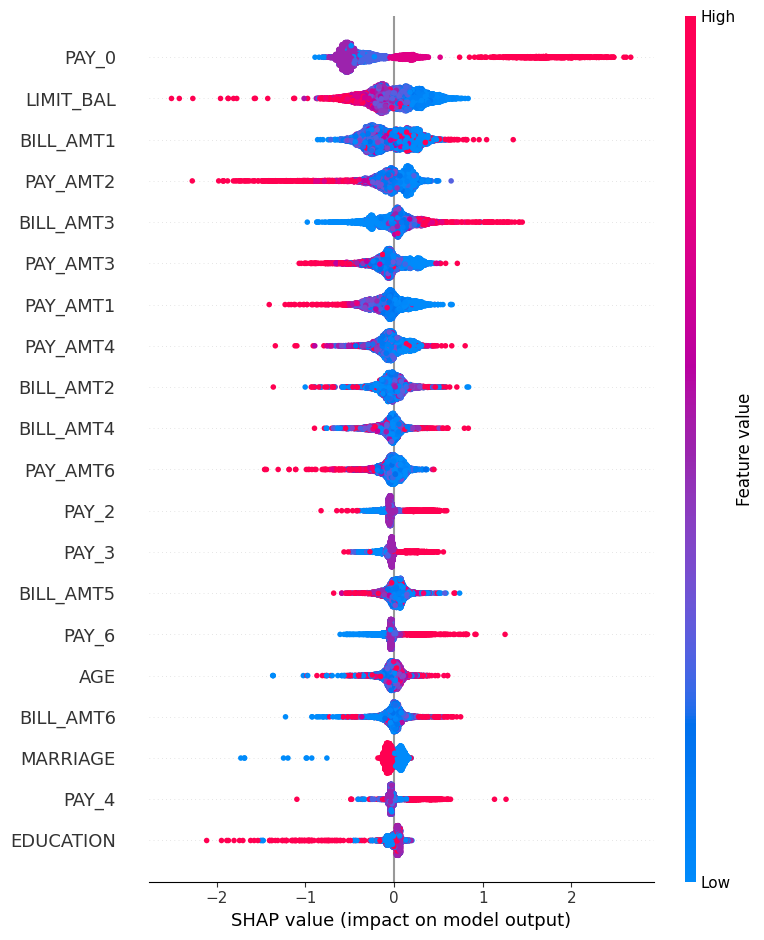

array([[ 0.49843338,  0.058007  ,  0.06049807, ...,  0.08964901,
        -0.0137112 ,  0.0079993 ],
       [-0.07339969, -0.06330118, -0.07442042, ..., -0.17593257,
         0.02283326, -0.06793111],
       [ 0.5553791 , -0.08284207,  0.0296725 , ..., -0.10322404,
        -0.06128983, -0.05594544],
       ...,
       [ 0.41098657, -0.04926979, -0.06422397, ..., -0.09690215,
        -0.15613982,  0.11181706],
       [ 0.33390224, -0.03513831, -0.05459261, ..., -0.24615413,
         0.02541915,  0.05539684],
       [-0.81544304, -0.07160541, -0.02293503, ...,  0.00873575,
        -0.34284472,  0.06508704]], shape=(6000, 23), dtype=float32)

In [57]:
explain.shap_exp_gradient(X_test, model_tuned)

### LightGBM

#### Base Model

In [58]:
lgb_model = train.data_model(X_train, y_train, lgb.LGBMClassifier(scale_pos_weight=weight_adjust, num_leaves=100, 
                                                                    max_depth=-1, learning_rate=0.1, n_estimators=250,
                                                                    random_state=42))
lgb_base_vals = evaluate.evaluate_model(lgb_model, X_test, y_test, output_dict=True)
print(evaluate.evaluate_model(lgb_model, X_test, y_test, output_dict=True))

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221792 -> initscore=-1.255256
[LightGBM] [Info] Start training from score -1.255256
{'0': {'precision': 0.8644506799050291, 'recall': 0.8544911457222104, 'f1-score': 0.8594420600858369, 'support': 4687.0}, '1': {'precision': 0.5010972933430871, 'recall': 0.5217060167555218, 'f1-score': 0.5111940298507462, 'support': 1313.0}, 'accuracy': 0.7816666666666666, 'macro avg': {'precision': 0.6827739866240581, 'recall': 0.688098581238866, 'f1-score': 0.6853180449682916, 'support': 6000.0}, 'weighted avg': {'precision': 0.78493684

### Hyperparameter Tuning

In [59]:
lgb_hyperparam_tuning = RandomizedSearchCV(estimator=lgb.LGBMClassifier(scale_pos_weight=weight_adjust, random_state=42),
                                       n_iter=10,
                                       param_distributions={'max_depth': [4,5,6],
                                                            'n_estimators': range(100,500),
                                                            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                       scoring='recall',
                                       random_state=42).fit(X_train, y_train)
print(lgb_hyperparam_tuning.best_params_)

[LightGBM] [Info] Number of positive: 4259, number of negative: 14941
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000541 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3260
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221823 -> initscore=-1.255075
[LightGBM] [Info] Start training from score -1.255075
[LightGBM] [Info] Number of positive: 4259, number of negative: 14941
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 23
[LightGBM] [Info] [b

### Tune Model & Hyperparameters

In [60]:
lgb_model_tuned = train.data_model(X_train, y_train, 
                               lgb.LGBMClassifier(scale_pos_weight=weight_adjust,
                                   random_state=42,
                                   max_depth=lgb_hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators=lgb_hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate=lgb_hyperparam_tuning.best_params_['learning_rate']))
lgb_tuned_vals = evaluate.evaluate_model(lgb_model_tuned, X_test, y_test, output_dict=True)

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221792 -> initscore=-1.255256
[LightGBM] [Info] Start training from score -1.255256
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

#### Comparisons

##### LGB vs. Tuned LGB

In [61]:
print(lgb_base_vals, lgb_tuned_vals)

{'0': {'precision': 0.8644506799050291, 'recall': 0.8544911457222104, 'f1-score': 0.8594420600858369, 'support': 4687.0}, '1': {'precision': 0.5010972933430871, 'recall': 0.5217060167555218, 'f1-score': 0.5111940298507462, 'support': 1313.0}, 'accuracy': 0.7816666666666666, 'macro avg': {'precision': 0.6827739866240581, 'recall': 0.688098581238866, 'f1-score': 0.6853180449682916, 'support': 6000.0}, 'weighted avg': {'precision': 0.784936847145724, 'recall': 0.7816666666666666, 'f1-score': 0.7832337828027245, 'support': 6000.0}} {'0': {'precision': 0.8760915742270474, 'recall': 0.7919778109665031, 'f1-score': 0.8319139399372478, 'support': 4687.0}, '1': {'precision': 0.446965399886557, 'recall': 0.6001523229246002, 'f1-score': 0.5123537061118335, 'support': 1313.0}, 'accuracy': 0.75, 'macro avg': {'precision': 0.6615284870568022, 'recall': 0.6960650669455517, 'f1-score': 0.6721338230245406, 'support': 6000.0}, 'weighted avg': {'precision': 0.7821844630755368, 'recall': 0.75, 'f1-score':

##### Tuned XGB vs. Tuned LGB

In [62]:
print(tuned_vals, lgb_tuned_vals)

{'0': {'precision': 0.8788238083945933, 'recall': 0.7906976744186046, 'f1-score': 0.8324348607367476, 'support': 4687.0}, '1': {'precision': 0.44980370162647226, 'recall': 0.6108149276466108, 'f1-score': 0.5180878552971576, 'support': 1313.0}, 'accuracy': 0.7513333333333333, 'macro avg': {'precision': 0.6643137550105328, 'recall': 0.7007563010326077, 'f1-score': 0.6752613580169526, 'support': 6000.0}, 'weighted avg': {'precision': 0.7849399083635029, 'recall': 0.7513333333333333, 'f1-score': 0.7636452577130507, 'support': 6000.0}} {'0': {'precision': 0.8760915742270474, 'recall': 0.7919778109665031, 'f1-score': 0.8319139399372478, 'support': 4687.0}, '1': {'precision': 0.446965399886557, 'recall': 0.6001523229246002, 'f1-score': 0.5123537061118335, 'support': 1313.0}, 'accuracy': 0.75, 'macro avg': {'precision': 0.6615284870568022, 'recall': 0.6960650669455517, 'f1-score': 0.6721338230245406, 'support': 6000.0}, 'weighted avg': {'precision': 0.7821844630755368, 'recall': 0.75, 'f1-scor

##### Confusion Matrix

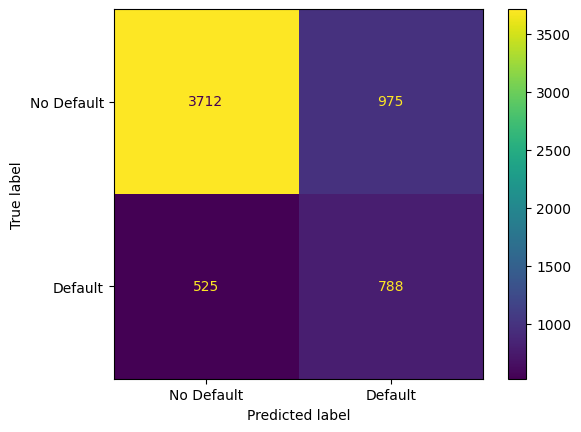

In [63]:
y_pred_lgb = lgb_model_tuned.predict(X_test)
cm = confusion_matrix(y_test, y_pred_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default','Default'])
disp.plot()
plt.show()

##### SHAP Explainability - LGB

/Users/mychellehale/Documents/DataSciencePrep/dev/creditlens/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


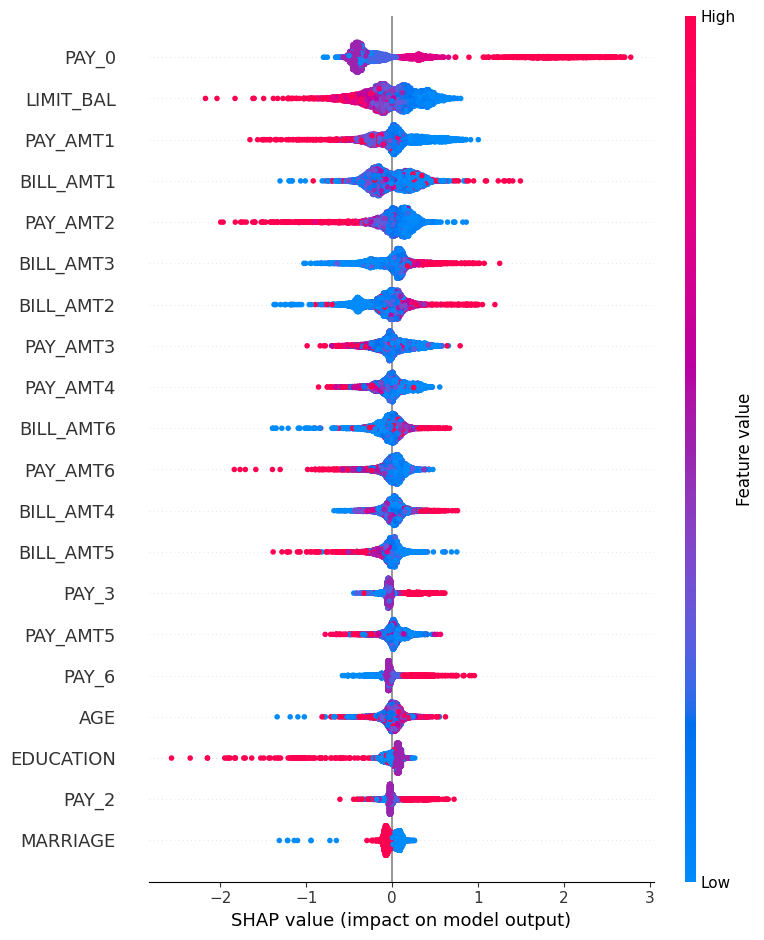

array([[ 0.53536248,  0.05969214,  0.08520979, ...,  0.04220651,
        -0.03349766,  0.04619267],
       [-0.0660609 , -0.07687712, -0.13820773, ..., -0.18330493,
         0.05466914,  0.02007612],
       [ 0.44627619, -0.07494607,  0.03472887, ..., -0.07973108,
        -0.03124891,  0.00832404],
       ...,
       [ 0.44138954, -0.04762818, -0.09524551, ..., -0.0325604 ,
        -0.11970258,  0.2781839 ],
       [ 0.13016398, -0.02760477, -0.04121915, ..., -0.10776303,
         0.05083121,  0.11360422],
       [-1.00254547, -0.03100513, -0.00199269, ...,  0.12697133,
        -0.25705429, -0.03195573]], shape=(6000, 23))

In [64]:
explain.shap_exp_gradient(X_test, lgb_model_tuned)

### AUC-PR Evaluation

In [65]:
lgb_auc = evaluate.auc_eval(lgb_model_tuned, X_test, y_test)

## CatBoost

### Base Model

In [66]:
cat_cols = ['SEX','MARRIAGE','EDUCATION']
cgb_model = train.data_model(X_train, y_train, 
                             CatBoostClassifier(
                                 scale_pos_weight=weight_adjust,
                                 random_seed=42,
                                 iterations=200, 
                                 learning_rate=0.1, 
                                 cat_features=cat_cols))
cgb_base_vals = evaluate.evaluate_model(cgb_model, X_test, y_test, output_dict=True)

0:	learn: 0.6694209	total: 35.3ms	remaining: 7.02s
1:	learn: 0.6494151	total: 58.1ms	remaining: 5.75s
2:	learn: 0.6352811	total: 73.6ms	remaining: 4.83s
3:	learn: 0.6218658	total: 94ms	remaining: 4.61s
4:	learn: 0.6121284	total: 107ms	remaining: 4.18s
5:	learn: 0.6025728	total: 125ms	remaining: 4.03s
6:	learn: 0.5951917	total: 140ms	remaining: 3.85s
7:	learn: 0.5894977	total: 154ms	remaining: 3.69s
8:	learn: 0.5844542	total: 169ms	remaining: 3.6s
9:	learn: 0.5807907	total: 182ms	remaining: 3.46s
10:	learn: 0.5776483	total: 192ms	remaining: 3.31s
11:	learn: 0.5744591	total: 206ms	remaining: 3.23s
12:	learn: 0.5716377	total: 222ms	remaining: 3.2s
13:	learn: 0.5699463	total: 236ms	remaining: 3.13s
14:	learn: 0.5679695	total: 249ms	remaining: 3.08s
15:	learn: 0.5666852	total: 261ms	remaining: 3s
16:	learn: 0.5652865	total: 272ms	remaining: 2.93s
17:	learn: 0.5639073	total: 284ms	remaining: 2.87s
18:	learn: 0.5625120	total: 295ms	remaining: 2.81s
19:	learn: 0.5610513	total: 308ms	remaining:

In [67]:
print(evaluate.evaluate_model(cgb_model, X_test, y_test, output_dict= True))

{'0': {'precision': 0.8841955386805885, 'recall': 0.7949647962449328, 'f1-score': 0.8372093023255814, 'support': 4687.0}, '1': {'precision': 0.46192609182530797, 'recall': 0.6283320639756284, 'f1-score': 0.5324298160696999, 'support': 1313.0}, 'accuracy': 0.7585, 'macro avg': {'precision': 0.6730608152529483, 'recall': 0.7116484301102806, 'f1-score': 0.6848195591976407, 'support': 6000.0}, 'weighted avg': {'precision': 0.7917889080604246, 'recall': 0.7585, 'f1-score': 0.7705133914165859, 'support': 6000.0}}


### Hyperparameter Tuning

In [68]:
cgb_hyperparam_tuning = RandomizedSearchCV(estimator=CatBoostClassifier(scale_pos_weight=weight_adjust, random_seed=42),
                                       n_iter=10,
                                       param_distributions={'max_depth': [4,5,6],
                                                            'n_estimators': range(100,500),
                                                            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]},
                                       scoring='recall',
                                       random_state=42).fit(X_train, y_train)
print(cgb_hyperparam_tuning.best_params_)

0:	learn: 0.6906776	total: 10.6ms	remaining: 1.69s
1:	learn: 0.6882793	total: 17.9ms	remaining: 1.41s
2:	learn: 0.6857919	total: 23.6ms	remaining: 1.24s
3:	learn: 0.6835278	total: 28.4ms	remaining: 1.11s
4:	learn: 0.6812777	total: 34.9ms	remaining: 1.08s
5:	learn: 0.6788625	total: 39.3ms	remaining: 1.01s
6:	learn: 0.6768212	total: 43.7ms	remaining: 955ms
7:	learn: 0.6746747	total: 48.8ms	remaining: 927ms
8:	learn: 0.6725834	total: 52.8ms	remaining: 887ms
9:	learn: 0.6704028	total: 57.7ms	remaining: 865ms
10:	learn: 0.6683888	total: 62.1ms	remaining: 841ms
11:	learn: 0.6664439	total: 66.3ms	remaining: 818ms
12:	learn: 0.6645660	total: 70.4ms	remaining: 796ms
13:	learn: 0.6626453	total: 74.1ms	remaining: 773ms
14:	learn: 0.6607389	total: 78.1ms	remaining: 755ms
15:	learn: 0.6586275	total: 82ms	remaining: 738ms
16:	learn: 0.6567176	total: 85.7ms	remaining: 721ms
17:	learn: 0.6550063	total: 89.8ms	remaining: 708ms
18:	learn: 0.6531590	total: 93.6ms	remaining: 694ms
19:	learn: 0.6514556	tot

In [69]:
cgb_model_tuned = train.data_model(X_train, y_train, 
                               CatBoostClassifier(scale_pos_weight=weight_adjust,
                                   random_seed=42,
                                   max_depth=cgb_hyperparam_tuning.best_params_['max_depth'],
                                   n_estimators=cgb_hyperparam_tuning.best_params_['n_estimators'],
                                   learning_rate=cgb_hyperparam_tuning.best_params_['learning_rate']))
cgb_tuned_vals = evaluate.evaluate_model(cgb_model_tuned, X_test, y_test, output_dict=True)

0:	learn: 0.6370889	total: 27ms	remaining: 3.38s
1:	learn: 0.6075582	total: 52.5ms	remaining: 3.26s
2:	learn: 0.5878770	total: 68.8ms	remaining: 2.82s
3:	learn: 0.5772846	total: 84.5ms	remaining: 2.58s
4:	learn: 0.5722490	total: 93.8ms	remaining: 2.27s
5:	learn: 0.5678414	total: 100ms	remaining: 2s
6:	learn: 0.5649136	total: 110ms	remaining: 1.87s
7:	learn: 0.5625628	total: 123ms	remaining: 1.81s
8:	learn: 0.5596535	total: 133ms	remaining: 1.73s
9:	learn: 0.5576710	total: 137ms	remaining: 1.59s
10:	learn: 0.5556150	total: 142ms	remaining: 1.49s
11:	learn: 0.5541828	total: 146ms	remaining: 1.39s
12:	learn: 0.5531117	total: 150ms	remaining: 1.31s
13:	learn: 0.5518563	total: 154ms	remaining: 1.23s
14:	learn: 0.5505263	total: 159ms	remaining: 1.17s
15:	learn: 0.5499726	total: 163ms	remaining: 1.12s
16:	learn: 0.5493043	total: 171ms	remaining: 1.09s
17:	learn: 0.5485095	total: 176ms	remaining: 1.06s
18:	learn: 0.5480493	total: 182ms	remaining: 1.02s
19:	learn: 0.5468508	total: 186ms	remaini

In [70]:
print(tuned_vals, lgb_tuned_vals, cgb_tuned_vals)

{'0': {'precision': 0.8788238083945933, 'recall': 0.7906976744186046, 'f1-score': 0.8324348607367476, 'support': 4687.0}, '1': {'precision': 0.44980370162647226, 'recall': 0.6108149276466108, 'f1-score': 0.5180878552971576, 'support': 1313.0}, 'accuracy': 0.7513333333333333, 'macro avg': {'precision': 0.6643137550105328, 'recall': 0.7007563010326077, 'f1-score': 0.6752613580169526, 'support': 6000.0}, 'weighted avg': {'precision': 0.7849399083635029, 'recall': 0.7513333333333333, 'f1-score': 0.7636452577130507, 'support': 6000.0}} {'0': {'precision': 0.8760915742270474, 'recall': 0.7919778109665031, 'f1-score': 0.8319139399372478, 'support': 4687.0}, '1': {'precision': 0.446965399886557, 'recall': 0.6001523229246002, 'f1-score': 0.5123537061118335, 'support': 1313.0}, 'accuracy': 0.75, 'macro avg': {'precision': 0.6615284870568022, 'recall': 0.6960650669455517, 'f1-score': 0.6721338230245406, 'support': 6000.0}, 'weighted avg': {'precision': 0.7821844630755368, 'recall': 0.75, 'f1-scor

##### Confusion Matrix

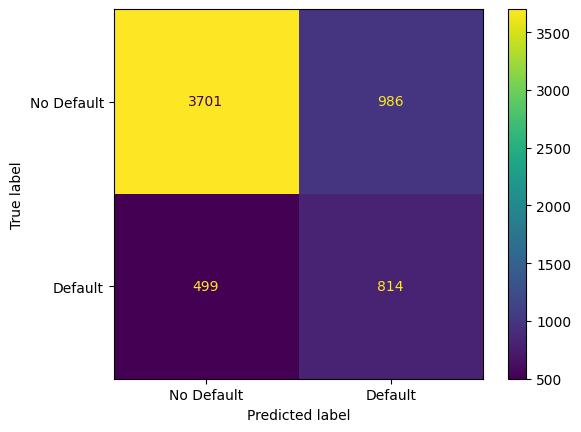

In [71]:
y_pred_cgb = cgb_model_tuned.predict(X_test)
cgb_cm = confusion_matrix(y_test, y_pred_cgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cgb_cm, display_labels=['No Default','Default'])
disp.plot()
plt.show()

#### Explainability: SHAP Values & AUC-PR

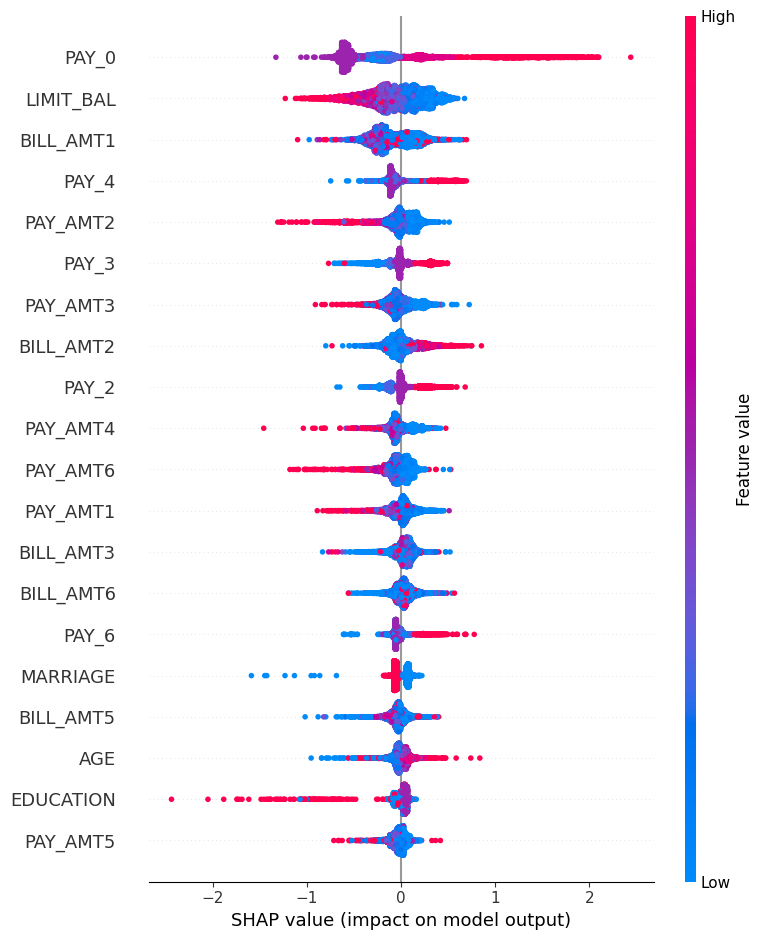

array([[ 0.42384591,  0.07333796,  0.05249393, ...,  0.03052872,
        -0.04636311,  0.01579503],
       [-0.07008538, -0.07760105, -0.05142674, ..., -0.1187217 ,
        -0.04418556, -0.03669923],
       [ 0.19986292, -0.07920304,  0.03220681, ..., -0.07673884,
        -0.02627077, -0.01431913],
       ...,
       [ 0.26307066, -0.0402401 , -0.05832172, ..., -0.0676649 ,
        -0.22913512,  0.0239225 ],
       [ 0.18652693, -0.03430676, -0.10017122, ..., -0.03458591,
         0.07168107,  0.05278531],
       [-0.45903842, -0.0688592 ,  0.03183278, ..., -0.04457868,
        -0.48262095,  0.24246469]], shape=(6000, 23))

In [72]:
explain.shap_exp_gradient(X_test, cgb_model_tuned)

In [73]:
cgb_auc = evaluate.auc_eval(cgb_model_tuned, X_test, y_test)
evaluate.auc_eval(cgb_model, X_test, y_test)


((array([0.21883333, 0.21886981, 0.2189063 , ..., 1.        , 1.        ,
         1.        ], shape=(6000,)),
  array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.52322925e-03, 7.61614623e-04, 0.00000000e+00], shape=(6000,)),
  array([0.03028944, 0.03282341, 0.03417556, ..., 0.96738153, 0.97679493,
         0.97805826], shape=(5999,))),
 0.5442313703225214)

# Comparison Table

In [75]:
summary = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Recall (Class 1)': [tuned_vals['1']['recall'], lgb_tuned_vals['1']['recall'], cgb_tuned_vals['1']['recall']],
    'Precision (Class 1)': [tuned_vals['1']['precision'], lgb_tuned_vals['1']['precision'], cgb_tuned_vals['1']['precision']],
    'F1 (Class 1)': [tuned_vals['1']['f1-score'], lgb_tuned_vals['1']['f1-score'], cgb_tuned_vals['1']['f1-score']],
    'AUC-PR': [xgb_auc[1], lgb_auc[1], cgb_auc[1]],
})

best_idx = summary['Recall (Class 1)'].idxmax()

def highlight_best(row):
    return ['background-color: #ffd700; color: black' if row.name == best_idx else '' for _ in row]

summary.style.apply(highlight_best, axis=1)

,Model,Recall (Class 1),Precision (Class 1),F1 (Class 1),AUC-PR
0,XGBoost,0.610815,0.449804,0.518088,0.535085
1,LightGBM,0.600152,0.446965,0.512354,0.532202
2,CatBoost,0.619954,0.452222,0.522968,0.542407
